### Multiple Linear Regression 


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df_index = pd.read_csv(r"D:\Learning Data Science\Linear Regression\economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#Drop unneccesary column - "Unnamed", "year","month"
df_index.drop(columns=['Unnamed: 0','year','month'],axis = 1,inplace = True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
#Check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

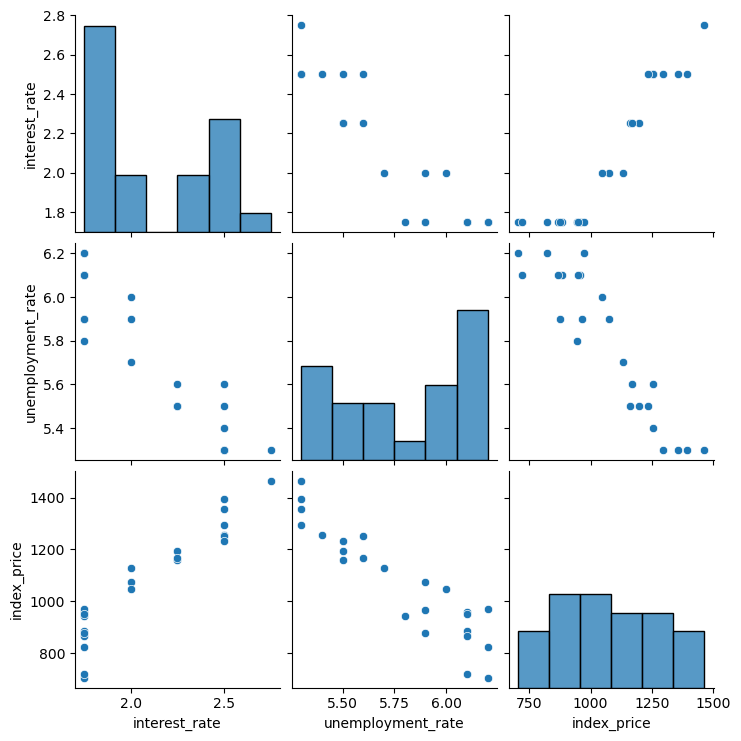

In [7]:
# Let's do some visualization 
import seaborn as sns
sns.pairplot(df_index)

In [8]:
# Correlation
df_index.corr()


,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

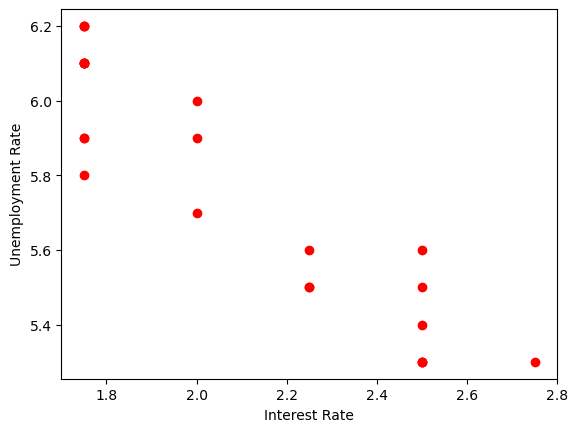

In [9]:
## Visualize the datapoints more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color = 'red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

In [10]:
# Independent and Dependent feature
# X = df_index[['interest_rate','unemployment_rate']] # Independent feature  
  #different way to represent 
X = df_index.iloc[:,:-1] # same way to represent the above Independent feature
y = df_index.iloc[:,-1] #Dependent Feature 

In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [12]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [13]:
# Train Test split 
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
import seaborn as sns

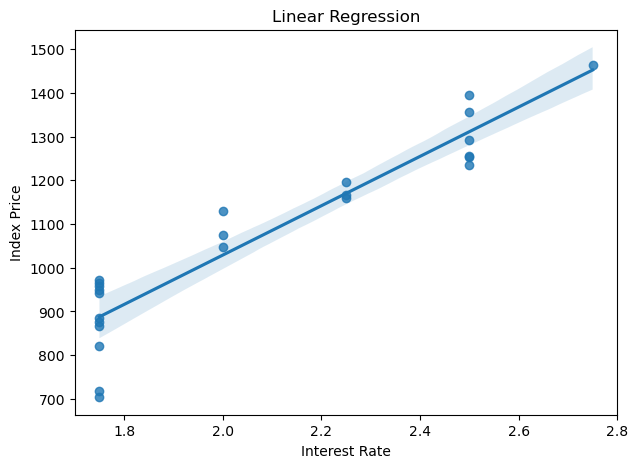

In [15]:
plt.figure(figsize=(7,5))
sns.regplot(x='interest_rate', y='index_price', data=df_index)
plt.xlabel("Interest Rate")
plt.ylabel("Index Price")
plt.title("Linear Regression")
plt.show()


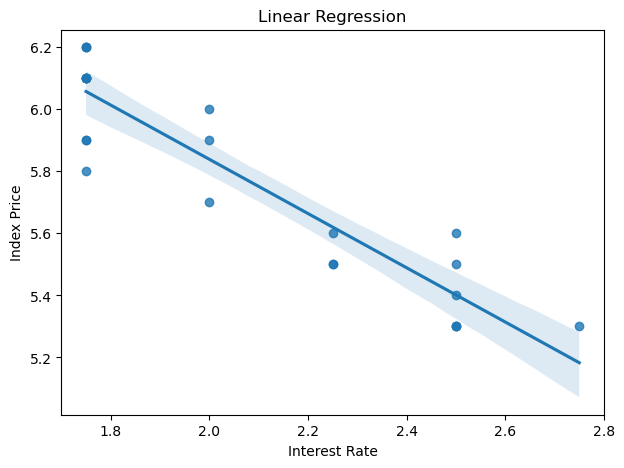

In [16]:
plt.figure(figsize=(7,5))
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)
plt.xlabel("Interest Rate")
plt.ylabel("Index Price")
plt.title("Linear Regression")
plt.show()

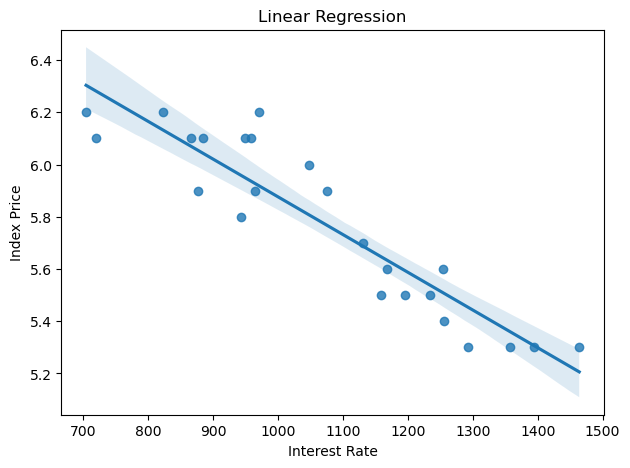

In [17]:
plt.figure(figsize=(7,5))
sns.regplot(x='index_price', y='unemployment_rate', data=df_index)
plt.xlabel("Interest Rate")
plt.ylabel("Index Price")
plt.title("Linear Regression")
plt.show()

In [18]:
# Standard scaling
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [20]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [21]:
X_test

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [22]:
from sklearn.linear_model import LinearRegression
regression  = LinearRegression()

In [23]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
#Cross Validation 
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv = 3 )

In [25]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [26]:
# Prediction 
y_pred = regression.predict(X_test)
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [27]:
# Performance Metrics 
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306611
73.80444932337099
90.04758423359624


In [28]:
# R^2 
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

# Display adjusted R-squared
print(1-(1-score)*(len(y_test)-1)/(len(y_test) - X_test.shape[1] - 1))

0.7591371539010254
0.5985619231683756


###  Assumptions

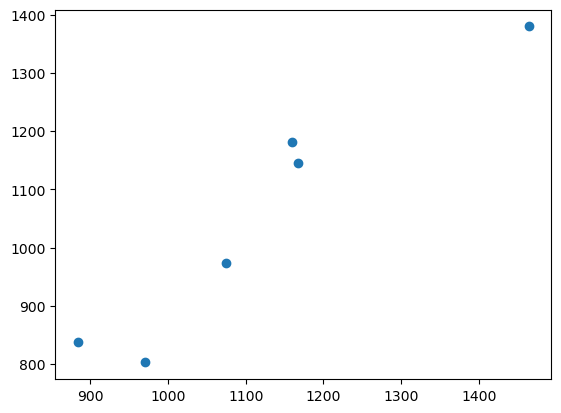

In [29]:
plt.scatter(y_test,y_pred)

In [30]:
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


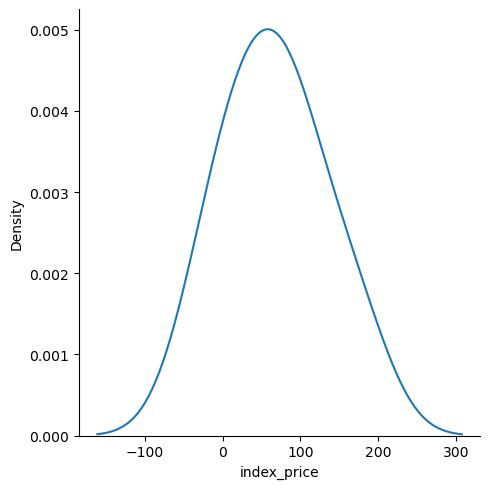

In [31]:
# Plot this Residuals
sns.displot(residuals,kind = 'kde')

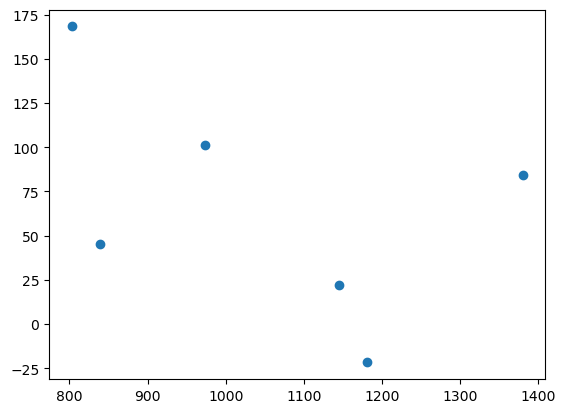

In [32]:
# Scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [33]:
# Ols Linear Regression 
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Tue, 02 Dec 2025   Prob (F-statistic):                       0.754
Time:                        22:17:03   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
print(regression.coef_)

[  88.27275507 -116.25716066]
